In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PROBLEM FORMULATION.

We consider regression problem with likelihood function
and assume noisy variance is known
so
$$ p(y|x ,\theta )=N(y|x^T \theta, \sigma^2), ⇐⇒\begin{multline*}y=x^{T}\theta\;+\;\epsilon,\;\epsilon\;\sim\;N\left(0,\sigma^2\right)\\ \end{multline*}$$
suppose D:={ ($x_1,y_1$),($x_2,y_2$),($x_3,y_3$), , ,   ,  ,($x_n,y_n$)} are given training sets
$$\prod^N_{n=1} p(y_n|x_n ,\theta )=\prod^N_{n=1} N(y_n|x_n^T \theta, \sigma^2)$$

we solve for the $\theta$ $$\theta=arg\space max\space p(y|x ,\theta )$$
$$-\log{\prod^N_{n=1} p(y_n|x_n ,\theta )}=-log{\sum^N_{n=1} p(y_n|x_n ,\theta )}$$
$$\log p(y_n|x_n ,\theta )=-\frac{1}{2\sigma^2}(y_n-x_n^T\theta)^2 +constant$$
constant terms are independent of the $\theta$ so we ingonre them.
Using negative log-likelihood $$\mathcal{L(\theta)}:=\frac{1}{2\sigma^2}\sum^N_{n=1}(y_n-x_n^T\theta)^2
=\frac{1}{2\sigma^2}||y_n-x_n^T\theta||^2$$
Computing gardient of the $\mathcal{L}$ with respect to $\theta$
$$\frac{d\mathcal{L}}{d\theta}=\frac{1}{\sigma^2}(-y^TX+\theta^TX^TX)$$
solve for the $\theta$ by  using $\frac{d\mathcal{L}}{d\theta}=0^T$
 we get $$\theta=(X^TX)^{-1}X^Ty$$
Remark. The maximum likelihood solution  requires us to solve a system of linear equations of the form Aθ = b with A =$X^TX \space and \space b=X^Ty$

 Setting the gradient to 0⊤ is a necessary and sufficient condition,
 and we obtain a global minimum.
belwo  we will see the implementation of the above formula.

 

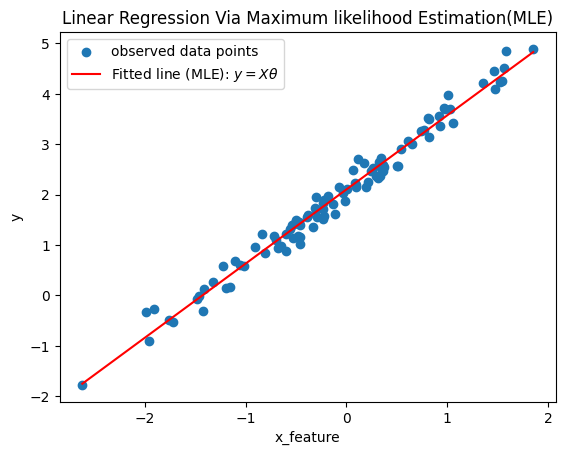

True value of parameters : [2.1 1.5]
Estimated value of  parameters via MLE: [2.10148557 1.47134857]


In [5]:
#The implementation of the maximum likelihood to estimate parameters 
np.random.seed(42)
#size of the sample points 
N=100
#randomly generated single features with N
x_feature=np.random.randn(N)

#add X_0 columns to X :-designing matrix (N,2) -
X=np.c_[np.ones(N),x_feature]
#noisy standard deviations(std) - std
sigma_mle=0.2

# intercept and slope values:- parameters value
theta_true=np.array([2.10, 1.5])#intercept=2.10, slope=1.50
#guassian noisy : mean is zero 
epsilon=np.random.normal(0,sigma_mle,size=N)

#y:= mx+b is linear regression 
y=X@theta_true + epsilon 
# MLE: solve (X^T X) theta = X^T y
A=X.T@X
b=X.T@y
#0_MLE:=(A^-1)bc- estimating theta by MLE
theta_mle=np.linalg.solve(A,b)
#dense grid
xx_feature=np.linspace(x_feature.min(),x_feature.max(),100)
XX=np.c_[np.ones(len(xx_feature)),xx_feature]
#predicted values of the y by using 0_MLE
y_hat=XX@theta_mle
#plot for visualizing:
plt.plot(figsize=(8,6))
plt.scatter(x_feature,y,label='observed data points')
plt.plot(xx_feature,y_hat,'r',label=r'Fitted line (MLE): $y = X\theta $')
plt.xlabel('x_feature')
plt.ylabel('y')
plt.title('Linear Regression Via Maximum likelihood Estimation(MLE)')
plt.legend()

plt.show()
print(f'True value of parameters : {theta_true}\nEstimated value of  parameters via MLE: {theta_mle}')

## Maximum likelihood Estimation with Features
- Linear Regression refers to Linear  in parameters in regression models but The inputs can undergo any nonlinear transformation,
for example polynomial functions.
So we do have 
$$ p(y\mid x,\theta)=\mathcal{N}\!\big(y\mid \phi(x)^T\theta, \, \sigma^2 \big)$$where $\phi$ is nonlinear transformation


We consider training inputs
$$ x_n\in \mathbb{R^D}\,\,,\,\, \,y_n \in \mathbb{R}, \quad n =1,\dots N ,$$  and define the features matrix (design matrix).

$$
\Phi =
\begin{bmatrix}
\phi_0(x_1)&\dots&\phi_{k-1}(x_1)\\
\phi_0(x_2)&\dots&\phi_{k-1}(x_2)\\
\vdots&\dots&\vdots\\
\phi_0(x_N)  &\dots&\phi_{k-1}(x_N)
\end{bmatrix}
$$
so , the maximum likelihood solution is:
$$
\theta_{ML} = (\Phi^T\Phi)^{-1}\Phi^Ty
$$

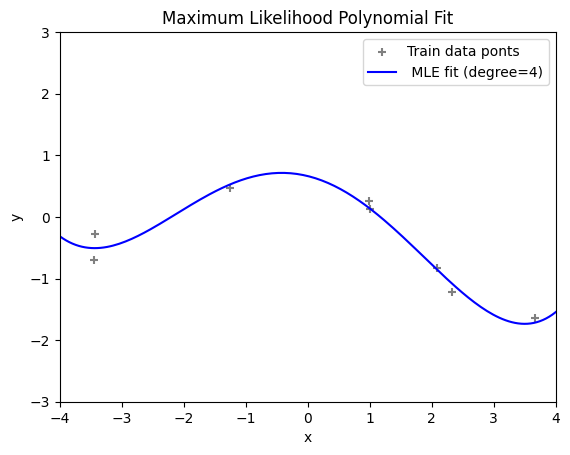

In [43]:
#implementation of Maximum likelihood Estimation with Features
#consider data set consists of N=10 pairs(x_n,y_n),
#where x_n∼U[−5,5]and y_n=−sin(x_n/5)+cos(x_n)+ϵ,where ϵ∼N(0,0.22) 

#
np.random.seed(42)
#polynomial degree  to fit
degre=4
#size of samples N

N=10
#x_n∼U[−5,5] -sample training from uniform distribution
x_n=np.random.uniform(-5,5,N)
#std
sigma_ml=0.2
#gaussian noisy with mean is zero
epsilon=np.random.normal(0,sigma_ml,size=N)
#y_n=−sin(x_n/5)+cos(x_n)+ϵ->target
y_n=-np.sin(x_n/5)+np.cos(x_n) + epsilon 
#design matrix of degree of polynomial: [1,x_n]-degree-1, ---[1,x_n,x_n*x_n,,,,x_n^4]-degree-4
phi=np.vstack([x_n**i for i in range (degre +1)]).T#design matrix with size (10,5)
#theta_MLe:-- A0_ml=b
A=phi.T@phi
b=phi.T@y_n
theta_ml=np.linalg.solve(A,b)

#plotting dense-grid
#evenly spaced points->new data points
xx=np.linspace(-5,5,200)

phi_xx=np.vstack([xx**i for i in range(degre+1)]).T

y_xx=phi_xx@theta_ml

plt.plot(figsize=(8,6))
plt.scatter(x_n,y_n,color='gray',marker='+',label ='Train data ponts');
plt.plot(xx,y_xx,'b',label=' MLE fit (degree=4)')
plt.xlabel('x')
plt.xlim(-4,4)
plt.ylim(-3,3)

plt.ylabel('y')
plt.title('Maximum Likelihood Polynomial Fit')
plt.legend()
plt.show()

# Estimating the Noise Variance

- Thus far, we assumed that the noise variance $\sigma^2$ is known.However, we can also use the principle of maximum likelihood estimation to obtain the maximum likelihood estimator $\sigma_{\text{ML}}^2$ for the noise variance.  To do this, we follow the standard procedure: we write down the log-likelihood,  compute its derivative with respect to $\sigma_{\text{ML}}^2$, with $\sigma_{\text{ML}}^2 > 0$,  
then set it to 0 and solve

$$
\log p(\mathcal{Y}\mid \mathcal{X},\theta,\sigma^2)=\sum_{n=1}^N{\log \mathcal{N(\mathcal{y_n}\mid \phi^T(\mathcal{x_n}) \theta,\sigma^2)}}
$$

$$
= -\frac{N}{2}\log \sigma^2 -\frac{1}{2\sigma^2}\sum_{n=1}^N(\mathcal{y_n}-\phi^T(\mathcal{x_n}) \theta)^2 +\text{constant}
$$
$$
\text{s}=\sum_{n=1}^N(\mathcal{y_n}-\phi^T(\mathcal{x_n}) \theta)^2
$$
$$
\frac{\partial \log p(\mathcal{Y}\mid \mathcal{X},\theta,\sigma^2)}{\partial \sigma^2}=-\frac{N}{2\sigma^2} + \frac{1}{2\sigma^4}= 0,
\iff \frac{N}{2\sigma^2}=\frac{s}{2\sigma^4}
$$
  so that
  $$
  \sigma_{\text{ML}}^2=\frac{s}{N}=\frac{1}{N}\sum_{n=1}^N(\mathcal{y_n}-\phi^T(\mathcal{x_n}) \theta)^2
  $$
  the maximum likelihood estimate of the noise variance is the
 empirical mean of the squared distances between the noise-free function
 value$\phi^T(\mathcal{x_n}) \theta$ and the corresponding noisy observations $y_n$ at input 
 locations $x_n$.  


n.

# Overfitting In Linear Regression 
- We can evaluate the quality of
 the model by computing the error/loss incurred, We ofen use the Root means square Error(RMSE) to evaluate the mdoel
- RMSE: allows us to compare errors of datasets with different sizes  and has the same scale and the same unit as the observed function values.

$$
  \sqrt{\frac{1}{N} \|{\mathcal{y_n}-\phi^T(\mathcal{x_n}) \theta)\|^2}}=\sqrt{\frac{1}{N}\sum_{n=1}^N(\mathcal{y_n}-\phi^T(\mathcal{x_n}) \theta)^2},
$$


For model selection , we can use the RMSE 
(or the  negative log-likelihood) to determine the best degree of the polynomial byfinding the polynomial degree M that minimizes the object function
Given that polynomial degree is a natural number ,we can perform a brute force search and numerate all(reasonable) values of M. for a training sets  of size N , it is sufficeint to test $0\leq M\leq N-1 $ . Below  will show  a number of polynomial  fits determined by maximum likelihood . 

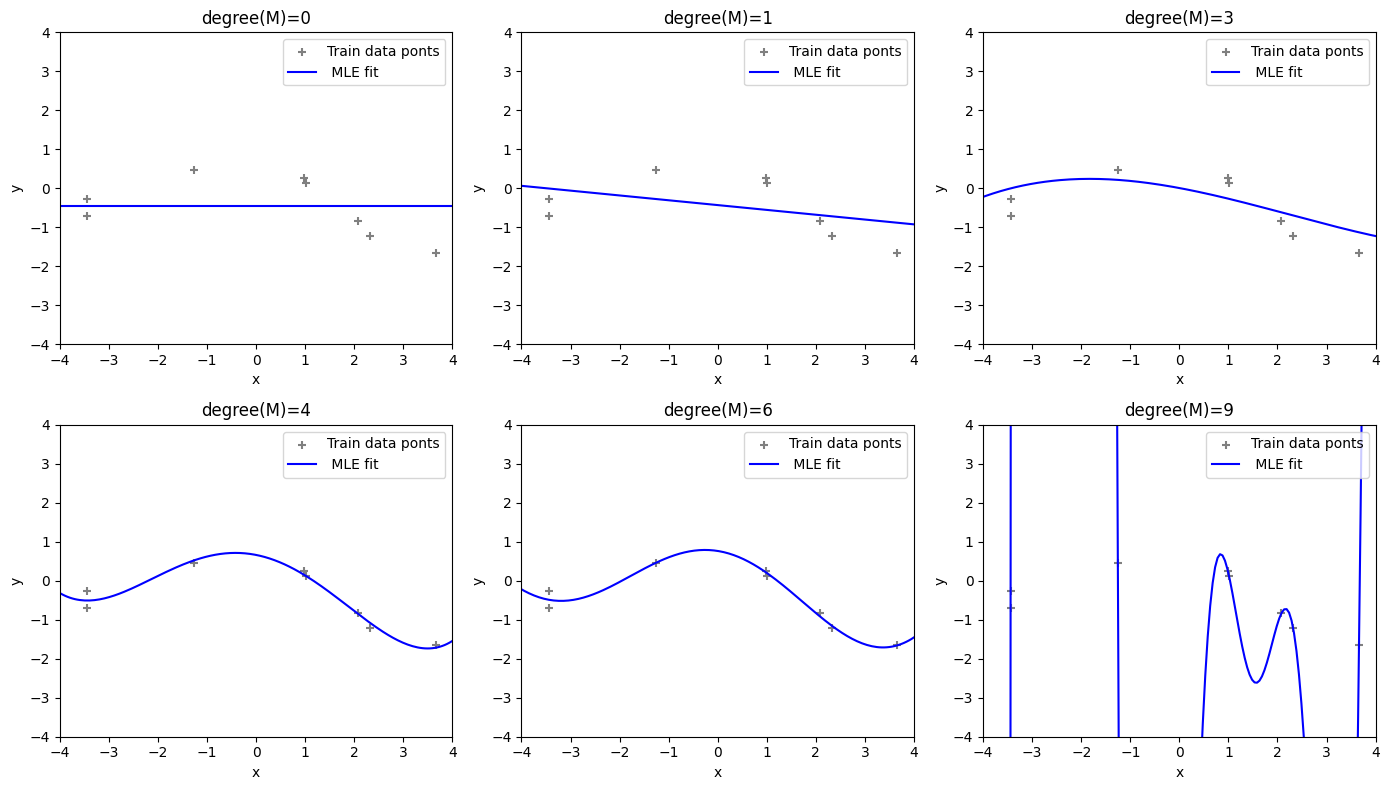

In [45]:
#number of polynomial  fits determined by maximum likelihood
#------------------------------------------------------------------------------------------------
np.random.seed(42)
#size of samples N

N=10
#polynomial degree  to fit

#x_n∼U[−5,5] -sample training from uniform distribution
x_n=np.random.uniform(-5,5,N)
#std
sigma_ml=0.2
#gaussian noisy with mean is zero
epsilon=np.random.normal(0,sigma_ml,size=N)
#y_n=−sin(x_n/5)+cos(x_n)+ϵ->target
y_n=-np.sin(x_n/5)+np.cos(x_n) + epsilon
#polynomial degree  to fit
degrees=[0,1,3,4,6,9]

#subplot grid (2 rows, 3 cols)
fig,axes=plt.subplots(2,3,figsize=(14,8))
for ax,M in zip(axes.ravel(),degrees):
    
    #design matrix of degree of polynomial: [1,x_n]-degree-1, ---[1,x_n,x_n*x_n,,,,x_n^4]-degree-4
    phi=np.vstack([x_n**i for i in range (M +1)]).T#design matrix with size (10,5)
    #theta_MLe:-- A0_ml=b
    A=phi.T@phi
    b=phi.T@y_n
    theta_ml=np.linalg.solve(A,b)
    
    #plotting dense-grid
    #evenly spaced points->new data points
    xx=np.linspace(-5,5,200)
    
    phi_xx=np.vstack([xx**i for i in range(M+1)]).T
    
    y_xx=phi_xx@theta_ml
    
   
    ax.scatter(x_n,y_n,color='gray',marker='+',label ='Train data ponts');
    ax.plot(xx,y_xx,'b',label=' MLE fit ')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(-4,4)
    ax.set_ylim(-4,4)
    ax.set_title(f'degree(M)={M}')
    ax.legend()
plt.tight_layout()    
plt.show()


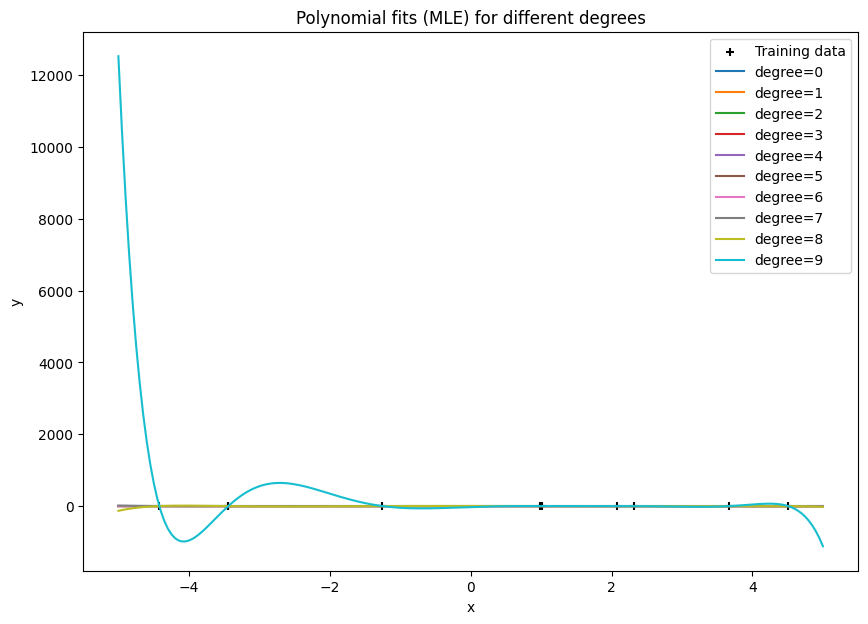

In [46]:


np.random.seed(42)

# sample size
N = 10
degre = N - 1

# training data
x_n = np.random.uniform(-5, 5, N)
sigma_ml = 0.2
epsilon = np.random.normal(0, sigma_ml, size=N)
y_n = -np.sin(x_n/5) + np.cos(x_n) + epsilon

# prepare dense grid for smooth curves
xx = np.linspace(-5, 5, 200)

plt.figure(figsize=(10,7))

# scatter training data once
plt.scatter(x_n, y_n, color='black', marker='+', label='Training data')

# loop through degrees
for k in range(degre + 1):
    # design matrix for training
    phi = np.vstack([x_n**i for i in range(k+1)]).T
    theta_ml = np.linalg.solve(phi.T @ phi, phi.T @ y_n)
    
    # prediction on dense grid
    phi_xx = np.vstack([xx**i for i in range(k+1)]).T
    y_xx = phi_xx @ theta_ml
    
    plt.plot(xx, y_xx, label=f'degree={k}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial fits (MLE) for different degrees')
plt.legend()
plt.show()


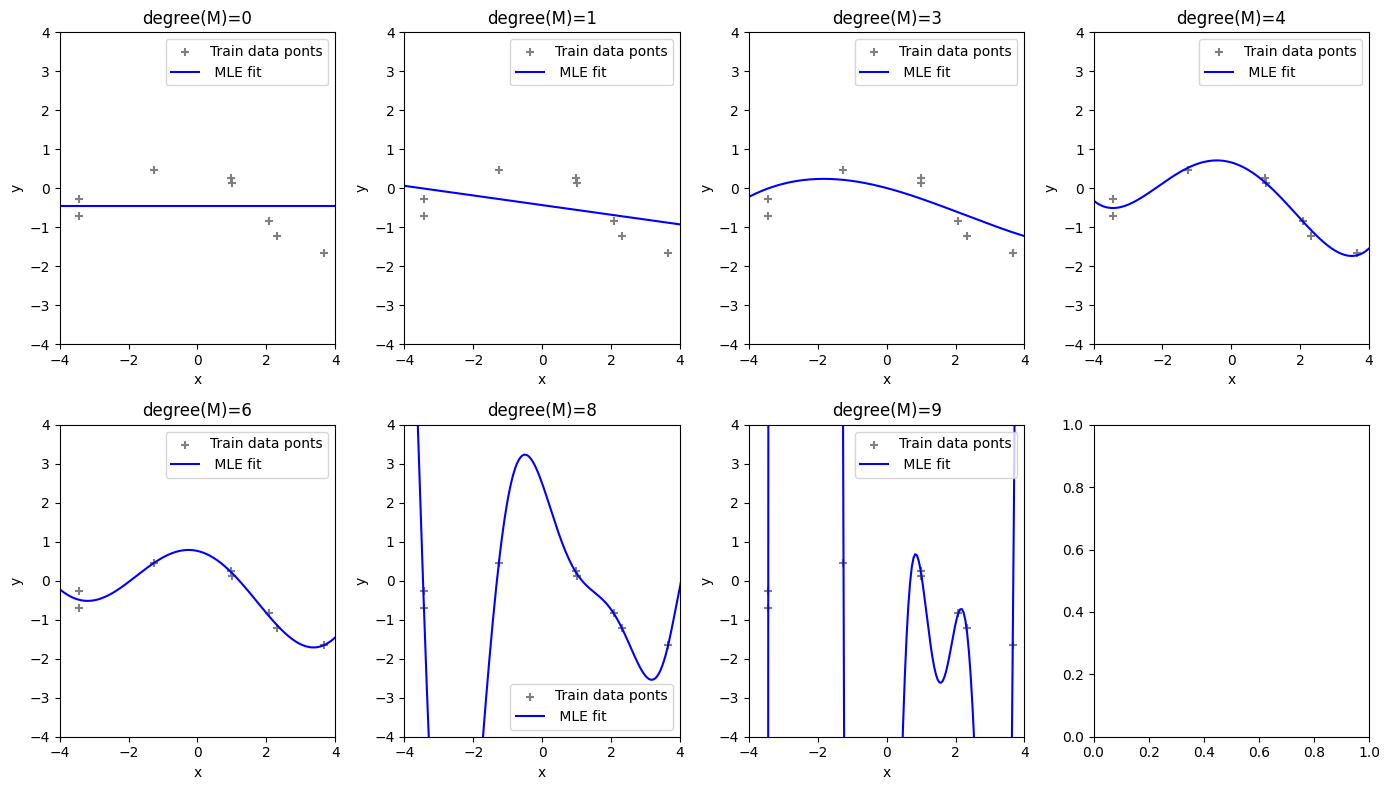

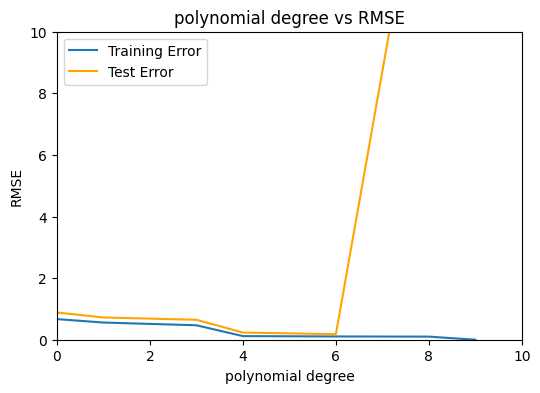

In [47]:
#number of polynomial  fits determined by maximum likelihood
#------------------------------------------------------------------------------------------------
np.random.seed(42)
#size of samples N

N=10
#polynomial degree  to fit

#x_n∼U[−5,5] -sample training from uniform distribution
x_n=np.random.uniform(-5,5,N)
#std
sigma_ml=0.2
#gaussian noisy with mean is zero
epsilon=np.random.normal(0,sigma_ml,size=N)
#y_n=−sin(x_n/5)+cos(x_n)+ϵ->target
y_n=-np.sin(x_n/5)+np.cos(x_n) + epsilon
#polynomial degree  to fit
degrees=[0,1,3,4,6,8,9]

#subplot grid (2 rows, 3 cols)
fig,axes=plt.subplots(2,4,figsize=(14,8))
#initializing empty root mean rmse
RMSE_train=[]
RMSE_test=[]


for ax,M in zip(axes.ravel(),degrees):
    
    #design matrix of degree of polynomial: [1,x_n]-degree-1, ---[1,x_n,x_n*x_n,,,,x_n^4]-degree-4
    phi=np.vstack([x_n**i for i in range (M +1)]).T#design matrix with size (10,5)
    #theta_MLe:-- A0_ml=b
    A=phi.T@phi
    b=phi.T@y_n
    theta_ml=np.linalg.solve(A,b)
    y_pred_train=phi@theta_ml
    
    
    RMSE_train.append(np.sqrt(np.mean((y_n-y_pred_train)**2))) 
    
    #plotting dense-grid
    #evenly spaced points->new data points
    xx=np.linspace(-5,5,200)
    
    yy=-np.sin(xx/5)+np.cos(xx)
    
    phi_xx=np.vstack([xx**i for i in range(M+1)]).T
    
    y_xx=phi_xx@theta_ml
    RMSE_test.append(np.sqrt(np.mean((yy-y_xx)**2))) 
    ax.scatter(x_n,y_n,color='gray',marker='+',label ='Train data ponts');
    ax.plot(xx,y_xx,'b',label=' MLE fit ')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(-4,4)
    ax.set_ylim(-4,4)
    ax.set_title(f'degree(M)={M}')
   
    
    ax.legend()

plt.tight_layout()    
plt.show()
#plot  Degree vs RMSE
plt.figure(figsize=(6,4))
plt.xlim(0,10)
plt.ylim(0,10)

plt.plot(degrees,RMSE_train,label='Training Error')
plt.plot(degrees,RMSE_test,'orange', label='Test Error')
plt.title("polynomial degree vs RMSE")
plt.xlabel('polynomial degree')
plt.ylabel('RMSE')
plt.legend()
plt.show()



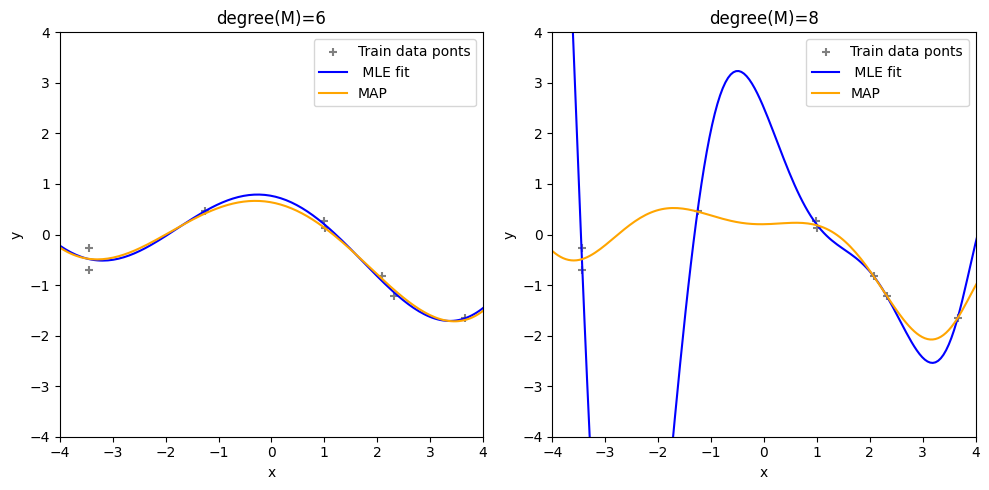

In [48]:
#---MAP-Maximum A posteriori Estimation(MAp)
#Guassian posteriori

np.random.seed(42)
N=10

degree=[6,8]
#x_n∼U[−5,5] -sample training from uniform distribution
x_n=np.random.uniform(-5,5,N)
#dense grid

#std
sigma_ml=0.2


#gaussian noisy with mean is zero

epsilon=np.random.normal(0,sigma_ml,size=N)

#y_n=−sin(x_n/5)+cos(x_n)+ϵ->target

y_n=-np.sin(x_n/5)+np.cos(x_n) + epsilon

# prior variance b^2
b2=1/4

fig,axes=plt.subplots(1,2, figsize=(10,5))
for ax, M in zip(axes.ravel(),degree):
   
    #design matrix of degree of polynomial: [1,x_n]-degree-1, 
    #                       ---[1,x_n,x_n*x_n,,,,x_n^4]-degree-4
    
    phi=np.vstack([x_n**i for i in range (M + 1)]).T#design matrix with size (10,5)
    
    #theta_MLe:-- A0_ml=b
    A=phi.T@phi
    
    b=phi.T@y_n
    
    theta_ml=np.linalg.solve(A,b)
    
    # theta_MAP:- (Φ^T Φ)^(-1) Φ^T y
    
    reg=(sigma_ml**2/b2) * np.eye(M+1)
    
    theta_Map=np.linalg.inv(phi.T@phi+ reg)@phi.T@y_n
    
    xx=np.linspace(-5,5,200)
    
    
    phi_xx=np.vstack([xx**i for i in range(M+1)]).T    

    y_xx=phi_xx@theta_ml
    
    y_xxx=phi_xx@theta_Map
    
    ax.scatter(x_n,y_n,color='gray',marker='+',
               label ='Train data ponts');
    
    ax.plot(xx,y_xx,'b',label=' MLE fit ')
    
    ax.plot(xx,y_xxx,'orange',label='MAP')
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(-4,4)
    ax.set_ylim(-4,4)

    ax.set_title(f'degree(M)={M}')
 
    ax.legend()

plt.tight_layout()    
plt.show()

## Bayesian Linear Regression

> **Maximum Likelihood Estimation (MLE)** can lead to severe overfitting,  
> particularly in the **small-data regime**.

**Maximum A Posteriori (MAP)** estimation addresses this issue by placing a **prior**
on the parameters, which plays the role of a **regularizer**.

**Bayesian Linear Regression** pushes this idea one step further.  
Instead of computing a **point estimate** of the parameters, we compute the **full
posterior distribution** over the parameters.


### Bayes’ Theorem

The posterior distribution over parameters is given by:

$$
p(\theta \mid X, Y) =
\frac{p(Y \mid X, \theta)\, p(\theta)}{p(Y \mid X)}
$$

where:
- $p(Y \mid X, \theta)$ is the **likelihood**
- $p(\theta)$ is the **prior**
- $p(Y \mid X)$ is the **marginal likelihood (evidencegin)**




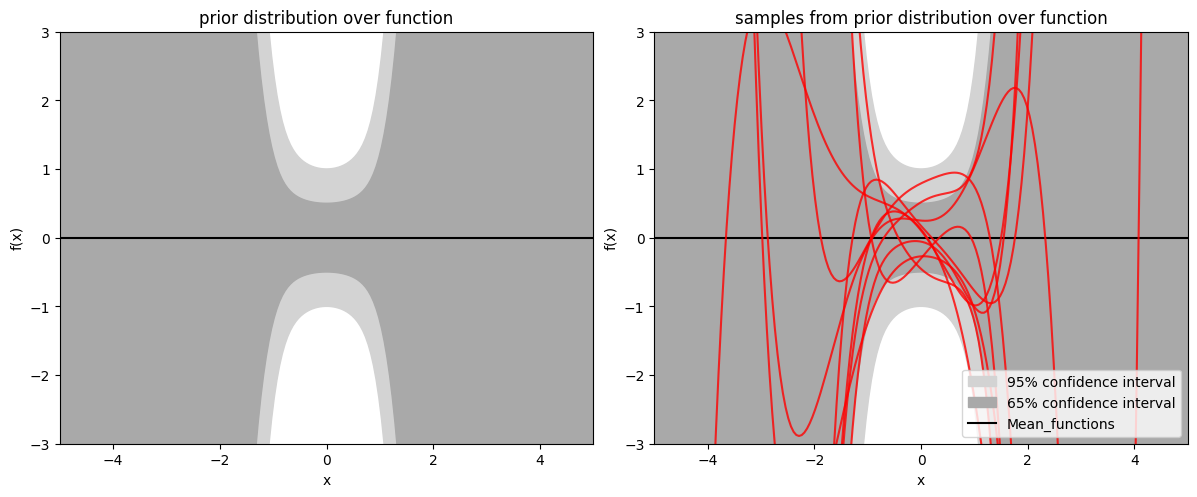

In [5]:
# Bayesian Linear Regression- --->  Prior Prediction  ---->

np.random.seed(42)
M=5 # degree
def feature_design(x,degree):
    '''Function that design features 
       matrix of the polynomian  
       by using degree 5 and return 
       features Matrix phi'''
    phi=np.vstack([x**i for i in range(degree+1) ])
    return phi.T
    
# prior parameters

mean_w=np.zeros(M+1)   #  m_0=0


cov_w=1/4*np.eye(M+1)  # s_0=b^2*I,   --> I is identity matrix


# prior distribution, --> theta ~ p(theta)

theta_samples=np.random.multivariate_normal(mean_w,
                                            cov_w,size=10)  # p(theta) =N(m),s_0)


x=np.linspace(-5,5,200)  # input points


phi=feature_design(x,M)  # feature function


f_samples=theta_samples@phi.T  # function samples --> f(x)*theta 

# predictive distribution parameters

mean_f=phi@mean_w    # avarege prediction 


var_f=np.sum(phi@cov_w*phi,axis=1)  # covariance of the predictive distr

std_f=np.sqrt(var_f)  # standard deviation

y_pred=np.random.normal(mean_f,var_f,size=mean_f.size)  # predictive distribution p(y/x) 

#  plot uncertainity

fig,axes=plt.subplots(1,2 ,figsize=(12,5))

    
 # ---plot----prior distribution over function   
axes[0].fill_between(x,
                     mean_f-2*std_f,mean_f+2*std_f,
                     color='lightgrey',label='95% confidence interval')

axes[0].fill_between(x,mean_f-std_f,mean_f+std_f,
                     color='darkgrey',
                     label='65% confidence interval')

axes[0].plot(x,mean_f,'k',label='Mean_functions')
axes[0].set_xlim(-5,5)
axes[0].set_ylim(-3,3)
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_title('prior distribution over function')


# --plot---samples from prior distribution over function---->
axes[1].fill_between(x,
                     mean_f-2*std_f,
                     mean_f+2*std_f,
                     color='lightgrey',
                     label='95% confidence interval')

axes[1].fill_between(x,
                     mean_f-std_f,
                     mean_f+std_f,
                     color='darkgrey',
                     label='65% confidence interval')
axes[1].plot(x,mean_f,'k',label='Mean_functions')

axes[1].plot(x,f_samples.T,color='r', alpha=0.8)
axes[1].legend()
axes[1].set_xlim(-5,5)
axes[1].set_ylim(-3,3)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('samples from prior distribution over function')

plt.tight_layout(pad=0.8)
plt.show()


In [7]:
theta_samples.shape
f_samples.shape

(10, 200)

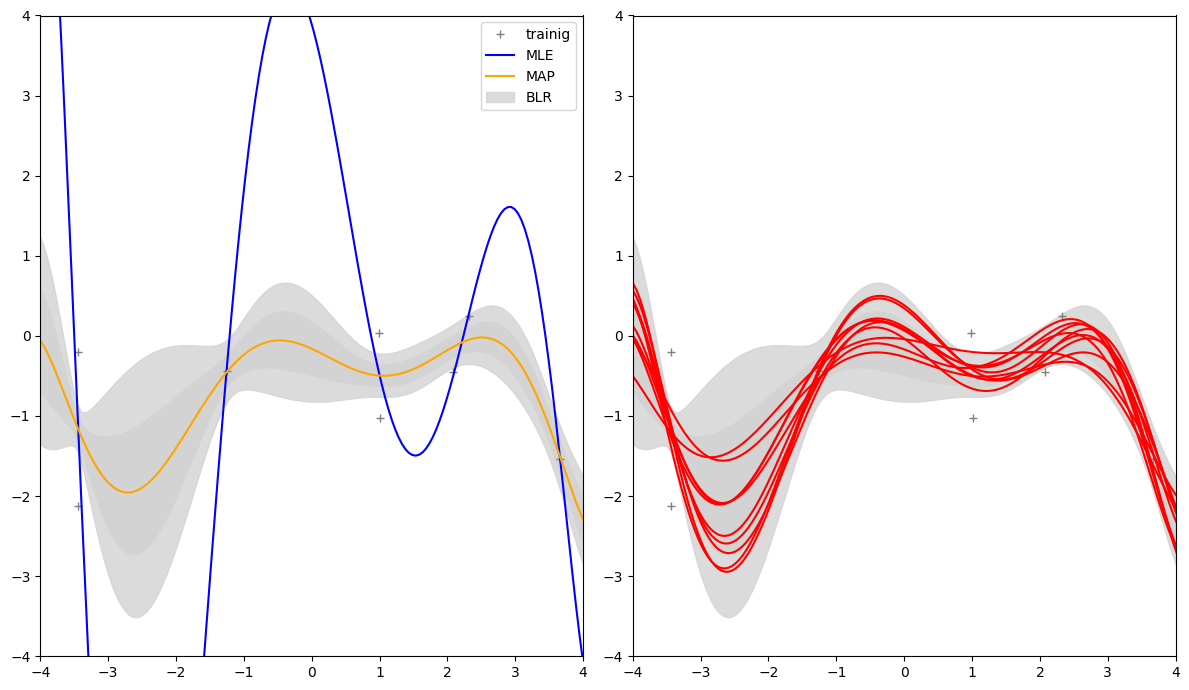

In [23]:
np.random.seed(42)
 
sigma=0.2
N=10 # size of samples or data sets
M= 7# degree of polynomial

# features samples
x_features=np.random.uniform(-5,5,N)

# guassian noisy
epsilon=np.random.normal(0,sigma,size=x_features.size)


y=-np.sin(x_features/5)+np.cos(x_features) +epsilon + np.random.randn(N)

phi=feature_design(x_features,M)
# parameters values by MLE
theta_mle=np.linalg.inv(phi.T@phi)@phi.T@y
# samples for the test 
test_sets=np.linspace(-5,5,200)
# design matrix for the test_sets
phi_test=feature_design(test_sets,M)
# predicted y 
y_MLE=phi_test@theta_mle

# b^2 for MAP
b2=1/4
reg=sigma**2/b2
# theta by MAP

theta_map=np.linalg.inv(phi.T@phi+reg*np.eye(M+1))@phi.T@y
# predicted by MAP
y_MAP=phi_test@theta_map
# Bayesian Regression

mean_w=np.zeros(M+1)  # mean of prior

cov_w=b2*np.eye(M+1)  # covariance of the prior

sigphi=(1/sigma**2)*phi.T
covmean=np.linalg.inv(cov_w)@mean_w # s_0^-1@mean_0 prior parameters multpily

cov_n=np.linalg.inv(np.linalg.inv(cov_w) + sigphi@phi) #  s_N posterior cov
mean_n=cov_n@(covmean + sigphi@y)      # m_N
posterior_theta=np.random.multivariate_normal(mean_n,cov_n,size=N)
posterior_pred=phi_test@posterior_theta.T

# mean function
mean_fx=phi_test@mean_n
#var_fx=np.sum(phi_test@cov_n*phi_test,axis=1)
var_fx = np.einsum('ij,jk,ik->i', phi_test, cov_n, phi_test)

std_fx=np.sqrt(var_fx)

fig,ax=plt.subplots(1,2,figsize=(12,7))
ax[0].plot(x_features,y,'+',color='grey',
                        label='trainig')

ax[0].plot(test_sets,y_MLE,'b',label='MLE')

ax[0].plot(test_sets,y_MAP, 'orange',
                      label='MAP')
ax[0].fill_between(test_sets,mean_fx-2*std_fx,
                mean_fx+2*std_fx,color='lightgray',
                label='BLR',alpha=0.8)

ax[0].fill_between(test_sets,mean_fx-std_fx,
                mean_fx+std_fx,color='lightgray')
#   ---------posterior plot----------------------> 

ax[1].plot(x_features,y,'+',color='grey',
                        label='trainig')
ax[1].plot(test_sets,posterior_pred,color='red')

ax[1].fill_between(test_sets,mean_fx-2*std_fx,
                mean_fx+2*std_fx,color='lightgray',
                label='BLR',alpha=0.8)

ax[1].fill_between(test_sets,mean_fx-std_fx,
                mean_fx+std_fx,color='lightgray')
ax[0].set_xlim(-4,4)
ax[0].set_ylim(-4,4)
ax[1].set_xlim(-4,4)
ax[1].set_ylim(-4,4)

ax[0].legend()


plt.tight_layout()
plt.show()

In [16]:
posterior_theta.shape
test_sets.shape,  posterior_theta.shape


((200,), (10, 8))

In [60]:
np.random.seed(42)
deg=2
n=10
x=np.array([1,2,3,4])
xx=np.vstack([x**i  for i in range (deg+1) ]).T
s_0=1/2*np.eye(2+1)
sx=xx@s_0
sxx=xx@s_0*xx
sxxx=xx@s_0@xx.T

In [57]:
sx=xx@s_0
sxx=xx@s_0@xx.T

In [58]:
print((sx*xx).shape)
sx*xx

(4, 3)


array([[  0.5,   0.5,   0.5],
       [  0.5,   2. ,   8. ],
       [  0.5,   4.5,  40.5],
       [  0.5,   8. , 128. ]])

In [63]:
sxxx

array([[  1.5,   3.5,   6.5,  10.5],
       [  3.5,  10.5,  21.5,  36.5],
       [  6.5,  21.5,  45.5,  78.5],
       [ 10.5,  36.5,  78.5, 136.5]])

In [62]:
np.sum(xx @ s_0 * xx, axis=1)

array([  1.5,  10.5,  45.5, 136.5])

In [70]:
#Bayesian Linear regression
np.random.seed(45)
std=0.2
a0=-0.3 
a1= 0.5

xn=np.random.uniform(-1,1,20)

#xn=np.vstack([xn**i for i in range(6)]).T
fx=a0+a1*xn+np.random.normal(0,std,20)
#theta_MLe=np.linalg.inv(xn.T@xn)@xn.T@fx
#p_0=np.random.multivariate_normal(mean_w,var_w,xn.size)

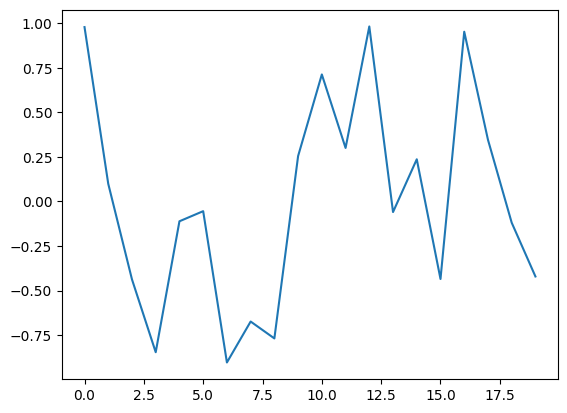

In [73]:
plt.plot(xn);

In [51]:
p_0=np.random.multivariate_normal(mean_w,var_w,xn.size)

In [ ]:
plt.plot(theta_MLe,fx);

In [27]:
p_0

array([[-0.12643326, -0.00761494,  0.19893275,  0.07115007,  0.46088089],
       [-0.11551488, -0.13031928,  0.37925735,  0.01713904, -0.37161582],
       [-0.05316745, -0.07546174, -0.32411445, -0.02702324,  0.23617312],
       [-0.08296558,  0.14684014, -0.19574554,  0.04681865, -0.18051539],
       [ 0.2307088 , -0.06384175, -0.05495341, -0.32503613, -0.3201323 ]])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# 1. Setup parameters
a0, a1 = -0.3, 0.5  # True intercept and slope
beta = (1/0.2)**2   # Precision (1/variance)
alpha = 2.0         # Prior precision

# 2. Grid for weight space visualization
w0, w1 = np.meshgrid(np.linspace(-1, 1, 100), np.linspace(-1, 1, 100))
w_grid = np.dstack((w0, w1))

# 3. Generate noisy data
x_data = np.random.uniform(-1, 1, 20)
t_data = a0 + a1 * x_data + np.random.normal(0, 0.2, 20)

# 4. Bayesian Update function
def update_posterior(x, t, m_prev, S_prev_inv):
    phi = np.array([1, x])
    S_n_inv = S_prev_inv + beta * np.outer(phi, phi)
    S_n = np.linalg.inv(S_n_inv)
    m_n = S_n @ (S_prev_inv @ m_prev + beta * t * phi)
    return m_n, S_n, S_n_inv
    
#print( update_posterior(x_data, t_data, m_prev, S_prev_inv))
# Initialization
#m_n = np.array([2, 2])
#S_n_inv = alpha * np.eye(2)
#S_n = np.linalg.inv(S_n_inv)
#
## You can now loop through your data points and update m_n, S_n
## Then use multivariate_normal(m_n, S_n).pdf(w_grid) to plot the heatmap.
#plt.plot(multivariate_normal(m_n, S_n).pdf(w_grid));